# Customer Segmentation and Shopping Pattern Analysis
## Mini Project - Unsupervised Learning

**Student ID:** 2025AIML049  
**Date:** May 2026

---

## Project Overview
This project analyzes consumer behavior and shopping habits through customer segmentation using multiple clustering algorithms and identifies key shopping patterns that influence purchasing decisions.

# 1. Data Preprocessing (2 marks)

## Tasks:
- Load and clean the dataset
- Handle missing values and duplicates
- Perform outlier detection and removal
- Feature scaling/normalization
- Create relevant features for both clustering and association analysis

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv('Shopping Trends And Customer Behaviour Dataset.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

Dataset loaded successfully!
Dataset shape: (3900, 18)

First few rows:
   Unnamed: 0  Customer ID  Age Gender Item Purchased  Category  \
0           0            1   55   Male         Blouse  Clothing   
1           1            2   19   Male        Sweater  Clothing   
2           2            3   50   Male          Jeans  Clothing   
3           3            4   21   Male        Sandals  Footwear   
4           4            5   45   Male         Blouse  Clothing   

   Purchase Amount (USD)       Location      Color  Season  Review Rating  \
0                     53       Kentucky       Gray  Winter            3.1   
1                     64          Maine     Maroon  Winter            3.1   
2                     73  Massachusetts     Maroon  Spring            3.1   
3                     90   Rhode Island     Maroon  Spring            3.5   
4                     49         Oregon  Turquoise  Spring            2.7   

  Subscription Status  Shipping Type Discount Applied Promo Co

In [2]:
# Check for missing values
print("Missing values in dataset:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Display basic statistics
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Missing values in dataset:
Unnamed: 0                0
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              3900 non-null   int64  
 1   Customer ID             3900 non-null   int64  
 2   Age                     3900 non-null   int64  
 3   Gender              

In [3]:
# Data Cleaning and Preprocessing
df_clean = df.copy()

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed. Shape after removing duplicates: {df_clean.shape}")

# Handle the index column if it exists
if df_clean.columns[0] == 'Unnamed: 0':
    df_clean = df_clean.drop('Unnamed: 0', axis=1)

# Identify numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")

# Outlier detection using IQR method for numeric columns
def detect_and_handle_outliers(data, cols):
    Q1 = data[cols].quantile(0.25)
    Q3 = data[cols].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((data[cols] < lower_bound) | (data[cols] > upper_bound)).any(axis=1)
    print(f"Outliers detected: {outliers.sum()} rows")
    return data[~outliers]

df_clean = detect_and_handle_outliers(df_clean, numeric_cols)
print(f"Dataset shape after outlier removal: {df_clean.shape}")
print("\nData cleaned successfully!")

Duplicates removed. Shape after removing duplicates: (3900, 18)

Numeric columns: ['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
Outliers detected: 0 rows
Dataset shape after outlier removal: (3900, 17)

Data cleaned successfully!


In [4]:
# Feature Engineering for clustering
# Encode categorical variables
le_dict = {}
categorical_cols = df_clean.select_dtypes(include=['object']).columns

df_encoded = df_clean.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

print(f"\nDataset shape after encoding: {df_encoded.shape}")
print("\nEncoded dataset sample:")
print(df_encoded.head())

Encoded Gender: 2 unique values
Encoded Item Purchased: 25 unique values
Encoded Category: 4 unique values
Encoded Location: 50 unique values
Encoded Color: 25 unique values
Encoded Season: 4 unique values
Encoded Subscription Status: 2 unique values
Encoded Shipping Type: 6 unique values
Encoded Discount Applied: 2 unique values
Encoded Promo Code Used: 2 unique values
Encoded Payment Method: 6 unique values
Encoded Frequency of Purchases: 7 unique values

Dataset shape after encoding: (3900, 17)

Encoded dataset sample:
   Customer ID  Age  Gender  Item Purchased  Category  Purchase Amount (USD)  \
0            1   55       1               2         1                     53   
1            2   19       1              23         1                     64   
2            3   50       1              11         1                     73   
3            4   21       1              14         2                     90   
4            5   45       1               2         1                   

In [5]:
# Feature Scaling/Normalization using StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

print("Feature scaling completed!")
print(f"\nScaled data shape: {df_scaled.shape}")
print("\nScaled data statistics (should be centered around 0):")
print(df_scaled.describe())

# Prepare data for clustering
X_cluster = df_scaled.copy()
print(f"\nData prepared for clustering: {X_cluster.shape}")

Feature scaling completed!

Scaled data shape: (3900, 17)

Scaled data statistics (should be centered around 0):
        Customer ID           Age       Gender  Item Purchased      Category  \
count  3.900000e+03  3.900000e+03  3900.000000    3.900000e+03  3.900000e+03   
mean   5.830094e-17 -1.985876e-16     0.000000    6.923237e-17  1.667043e-16   
std    1.000128e+00  1.000128e+00     1.000128    1.000128e+00  1.000128e+00   
min   -1.731607e+00 -1.714394e+00    -1.457738   -1.671990e+00 -1.117360e+00   
25%   -8.658034e-01 -8.594483e-01    -1.457738   -8.384529e-01 -1.117360e+00   
50%    0.000000e+00 -4.502378e-03     0.685994   -4.915732e-03 -2.001925e-03   
75%    8.658034e-01  8.504436e-01     0.685994    8.286215e-01 -2.001925e-03   
max    1.731607e+00  1.705390e+00     0.685994    1.662159e+00  2.228715e+00   

       Purchase Amount (USD)      Location         Color        Season  \
count           3.900000e+03  3.900000e+03  3.900000e+03  3.900000e+03   
mean           -1.

# 2. Customer Segmentation using Clustering (5 marks)

## 2.1 K-Means Clustering with Elbow Method (1.5 marks)

### Elbow Method to find optimal number of clusters

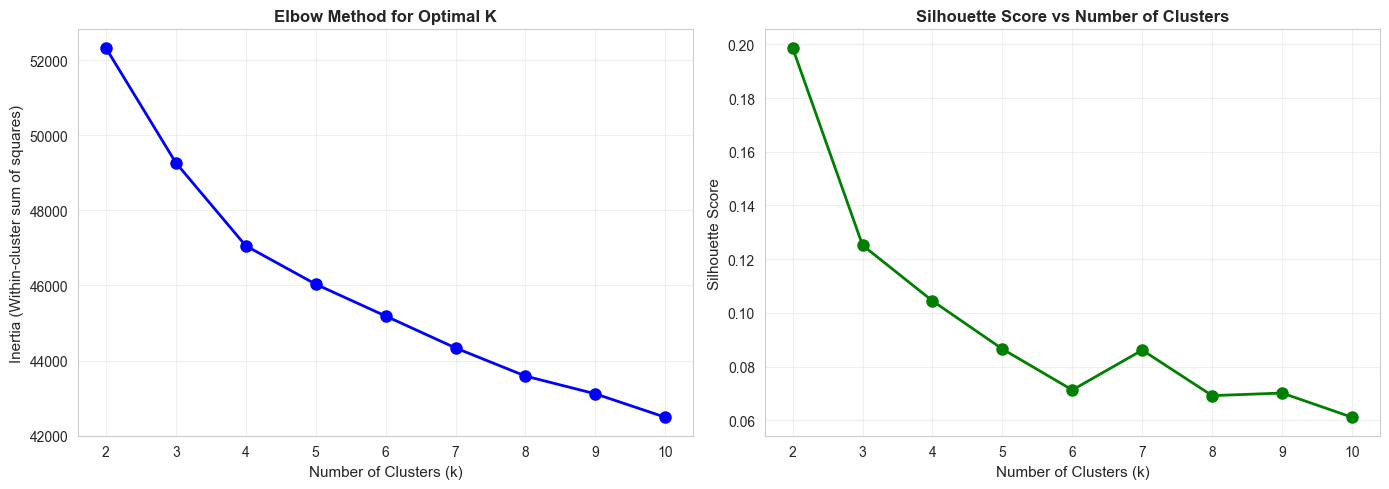

Optimal number of clusters based on Elbow method and Silhouette: 2
Silhouette scores for each k: {2: '0.1987', 3: '0.1252', 4: '0.1044', 5: '0.0865', 6: '0.0713', 7: '0.0861', 8: '0.0692', 9: '0.0701', 10: '0.0611'}


In [6]:
# Elbow Method for K-means
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_cluster, kmeans.labels_)
    silhouette_scores.append(sil_score)

# Plot Elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=11)
axes[0].set_title('Elbow Method for Optimal K', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on Elbow method and Silhouette: {optimal_k}")
print(f"Silhouette scores for each k: {dict(zip(K_range, [f'{s:.4f}' for s in silhouette_scores]))}")


K-Means Clustering Results (k=2):
Silhouette Score: 0.1987
Cluster distribution:
0    1677
1    2223
Name: count, dtype: int64


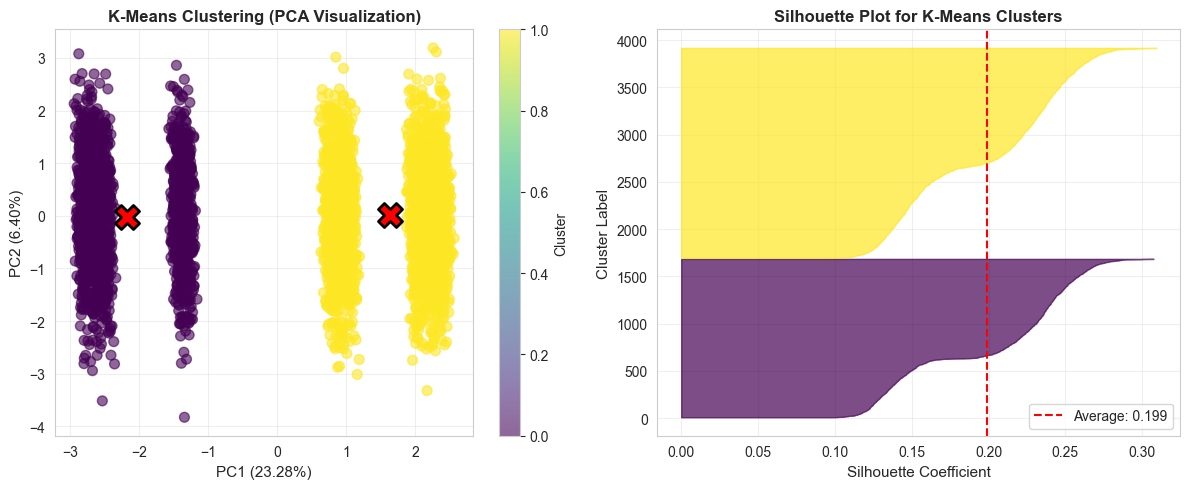

In [7]:
# Apply K-means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_clusters = kmeans_final.fit_predict(X_cluster)
kmeans_silhouette = silhouette_score(X_cluster, kmeans_clusters)

print(f"\nK-Means Clustering Results (k={optimal_k}):")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Cluster distribution:\n{pd.Series(kmeans_clusters).value_counts().sort_index()}")

# Visualize K-means clusters using PCA for 2D representation
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_clusters, cmap='viridis', s=50, alpha=0.6)
plt.scatter(pca.transform(kmeans_final.cluster_centers_)[:, 0], 
            pca.transform(kmeans_final.cluster_centers_)[:, 1], 
            marker='X', s=300, c='red', edgecolors='black', linewidth=2)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
plt.title('K-Means Clustering (PCA Visualization)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Silhouette plot for K-means
plt.subplot(1, 2, 2)
silhouette_vals = silhouette_samples(X_cluster, kmeans_clusters)
y_lower = 10
colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[kmeans_clusters == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, 
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    y_lower = y_upper + 10

plt.xlabel('Silhouette Coefficient', fontsize=11)
plt.ylabel('Cluster Label', fontsize=11)
plt.title('Silhouette Plot for K-Means Clusters', fontsize=12, fontweight='bold')
plt.axvline(x=kmeans_silhouette, color='red', linestyle='--', label=f'Average: {kmeans_silhouette:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.2 Hierarchical Clustering (1.5 marks)

Hierarchical (ward) - Silhouette Score: 0.1987
Hierarchical (complete) - Silhouette Score: 0.1977
Hierarchical (average) - Silhouette Score: 0.1985
Hierarchical (single) - Silhouette Score: 0.1188

Best linkage method: ward


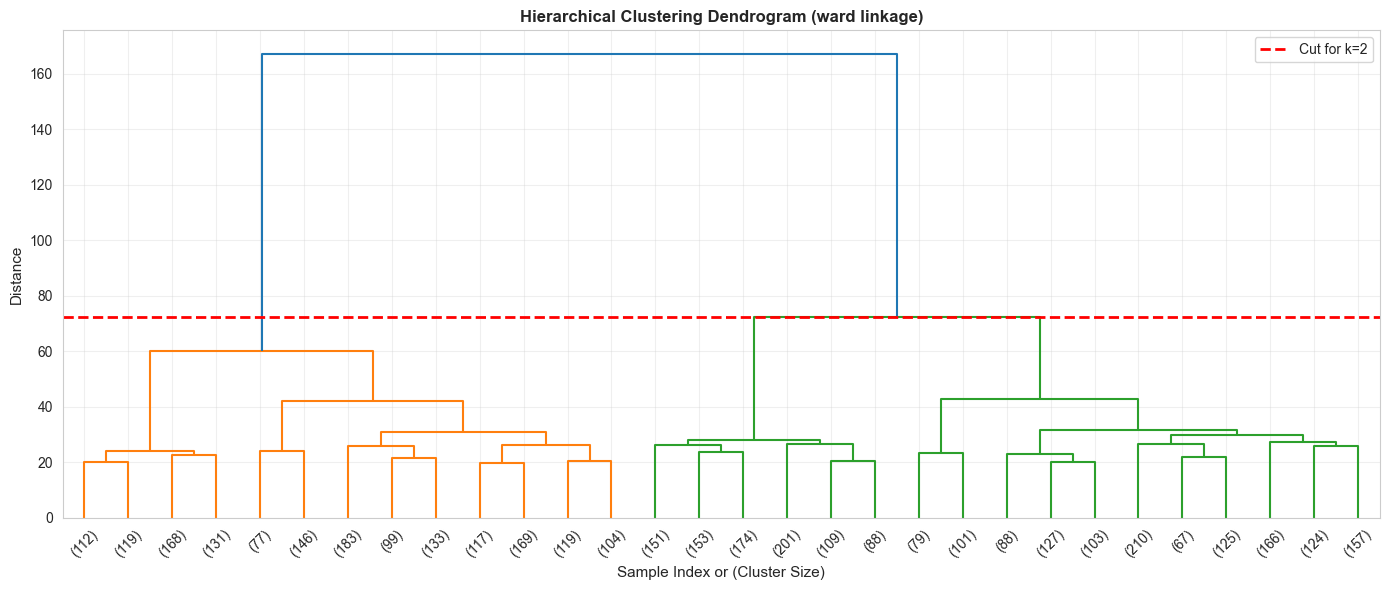

In [8]:
# Test different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']
hierarchical_silhouettes = {}

for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    hc_clusters = hc.fit_predict(X_cluster)
    sil_score = silhouette_score(X_cluster, hc_clusters)
    hierarchical_silhouettes[method] = sil_score
    print(f"Hierarchical ({method}) - Silhouette Score: {sil_score:.4f}")

# Use best linkage method
best_linkage = max(hierarchical_silhouettes, key=hierarchical_silhouettes.get)
print(f"\nBest linkage method: {best_linkage}")

# Create dendrogram with best method
Z = linkage(X_cluster, method=best_linkage)

plt.figure(figsize=(14, 6))
dendrogram(Z, leaf_font_size=10, truncate_mode='lastp', p=30)
plt.title(f'Hierarchical Clustering Dendrogram ({best_linkage} linkage)', fontsize=12, fontweight='bold')
plt.xlabel('Sample Index or (Cluster Size)', fontsize=11)
plt.ylabel('Distance', fontsize=11)
plt.axhline(y=Z[-optimal_k, 2], c='red', linestyle='--', linewidth=2, label=f'Cut for k={optimal_k}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Hierarchical Clustering Results (k=2, linkage=ward):
Silhouette Score: 0.1987
Cluster distribution:
0    2223
1    1677
Name: count, dtype: int64


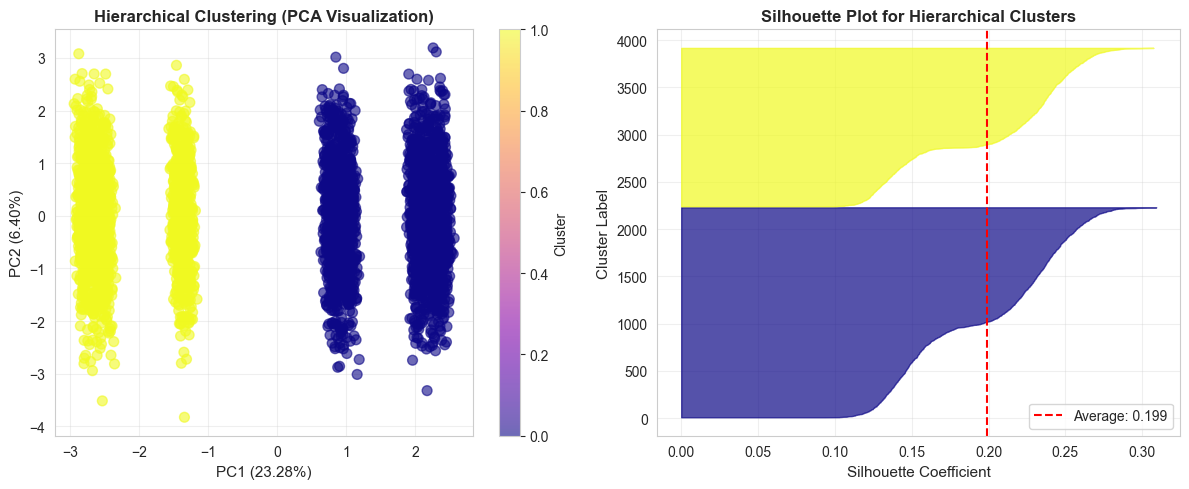

In [9]:
# Apply Hierarchical Clustering with best linkage
hc_final = AgglomerativeClustering(n_clusters=optimal_k, linkage=best_linkage)
hc_clusters = hc_final.fit_predict(X_cluster)
hc_silhouette = silhouette_score(X_cluster, hc_clusters)

print(f"\nHierarchical Clustering Results (k={optimal_k}, linkage={best_linkage}):")
print(f"Silhouette Score: {hc_silhouette:.4f}")
print(f"Cluster distribution:\n{pd.Series(hc_clusters).value_counts().sort_index()}")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_clusters, cmap='plasma', s=50, alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
plt.title('Hierarchical Clustering (PCA Visualization)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Silhouette plot for Hierarchical
plt.subplot(1, 2, 2)
silhouette_vals_hc = silhouette_samples(X_cluster, hc_clusters)
y_lower = 10
colors = plt.cm.plasma(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals_hc[hc_clusters == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, 
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    y_lower = y_upper + 10

plt.xlabel('Silhouette Coefficient', fontsize=11)
plt.ylabel('Cluster Label', fontsize=11)
plt.title('Silhouette Plot for Hierarchical Clusters', fontsize=12, fontweight='bold')
plt.axvline(x=hc_silhouette, color='red', linestyle='--', label=f'Average: {hc_silhouette:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3 DBSCAN Clustering (1 mark)

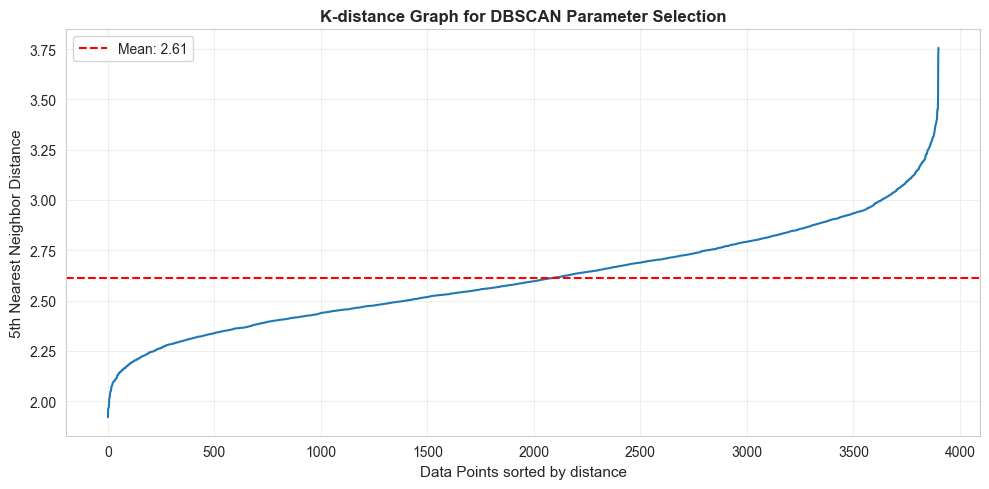

DBSCAN Parameters: eps=2.61, min_samples=5


In [10]:
# DBSCAN parameter tuning using k-distance graph
from sklearn.neighbors import NearestNeighbors

# Calculate k-distance for k=5
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_cluster)
distances, indices = neighbors_fit.kneighbors(X_cluster)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance', fontsize=11)
plt.ylabel('5th Nearest Neighbor Distance', fontsize=11)
plt.title('K-distance Graph for DBSCAN Parameter Selection', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=np.mean(distances), color='r', linestyle='--', label=f'Mean: {np.mean(distances):.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# Choose eps based on the elbow in the graph
eps_value = np.mean(distances)
min_samples = 5

print(f"DBSCAN Parameters: eps={eps_value:.2f}, min_samples={min_samples}")


DBSCAN Clustering Results:
Number of clusters: 6
Number of noise points (outliers): 617
Cluster distribution:
-1     617
 0     920
 1       2
 2     391
 3       4
 4       7
 5    1959
Name: count, dtype: int64
Silhouette Score (excluding noise): 0.0612


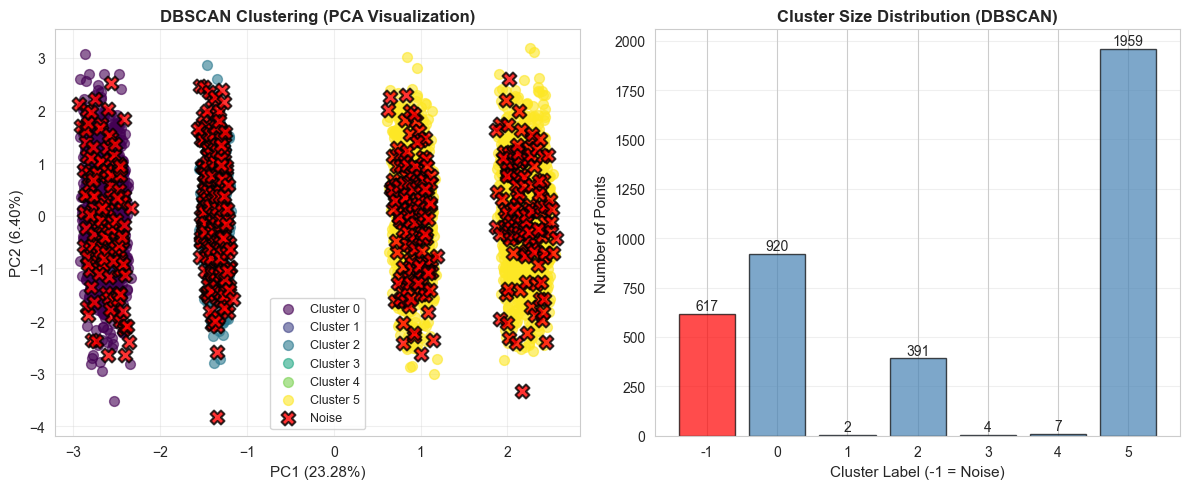

In [11]:
# Apply DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_clusters = dbscan.fit_predict(X_cluster)

# Count clusters and noise points
n_clusters_dbscan = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)
n_noise = list(dbscan_clusters).count(-1)

print(f"\nDBSCAN Clustering Results:")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points (outliers): {n_noise}")
print(f"Cluster distribution:\n{pd.Series(dbscan_clusters).value_counts().sort_index()}")

# Calculate Silhouette score (excluding noise points)
if n_clusters_dbscan > 1 and n_noise < len(dbscan_clusters):
    mask = dbscan_clusters != -1
    dbscan_silhouette = silhouette_score(X_cluster[mask], dbscan_clusters[mask])
    print(f"Silhouette Score (excluding noise): {dbscan_silhouette:.4f}")
else:
    dbscan_silhouette = -1
    print("Silhouette Score not calculable (need at least 2 clusters without all noise)")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Highlight noise points differently
colors = plt.cm.viridis(np.linspace(0, 1, n_clusters_dbscan))
for i in range(n_clusters_dbscan):
    mask = dbscan_clusters == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[i]], s=50, alpha=0.6, label=f'Cluster {i}')

# Noise points
noise_mask = dbscan_clusters == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='red', s=100, marker='X', 
            alpha=0.8, edgecolors='black', linewidth=1.5, label='Noise')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
plt.title('DBSCAN Clustering (PCA Visualization)', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# Cluster sizes
plt.subplot(1, 2, 2)
cluster_counts = pd.Series(dbscan_clusters).value_counts().sort_index()
colors_bar = ['red' if x == -1 else 'steelblue' for x in cluster_counts.index]
bars = plt.bar(range(len(cluster_counts)), cluster_counts.values, color=colors_bar, alpha=0.7, edgecolor='black')
plt.xlabel('Cluster Label (-1 = Noise)', fontsize=11)
plt.ylabel('Number of Points', fontsize=11)
plt.title('Cluster Size Distribution (DBSCAN)', fontsize=12, fontweight='bold')
plt.xticks(range(len(cluster_counts)), cluster_counts.index)
for i, (bar, count) in enumerate(zip(bars, cluster_counts.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), 
             ha='center', va='bottom', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 2.4 Clustering Performance Comparison


CLUSTERING ALGORITHMS COMPARISON
          Algorithm  Silhouette Score  Number of Clusters  Noise Points
            K-Means          0.198681                   2             0
Hierarchical (ward)          0.198681                   2             0
             DBSCAN          0.061207                   6           617


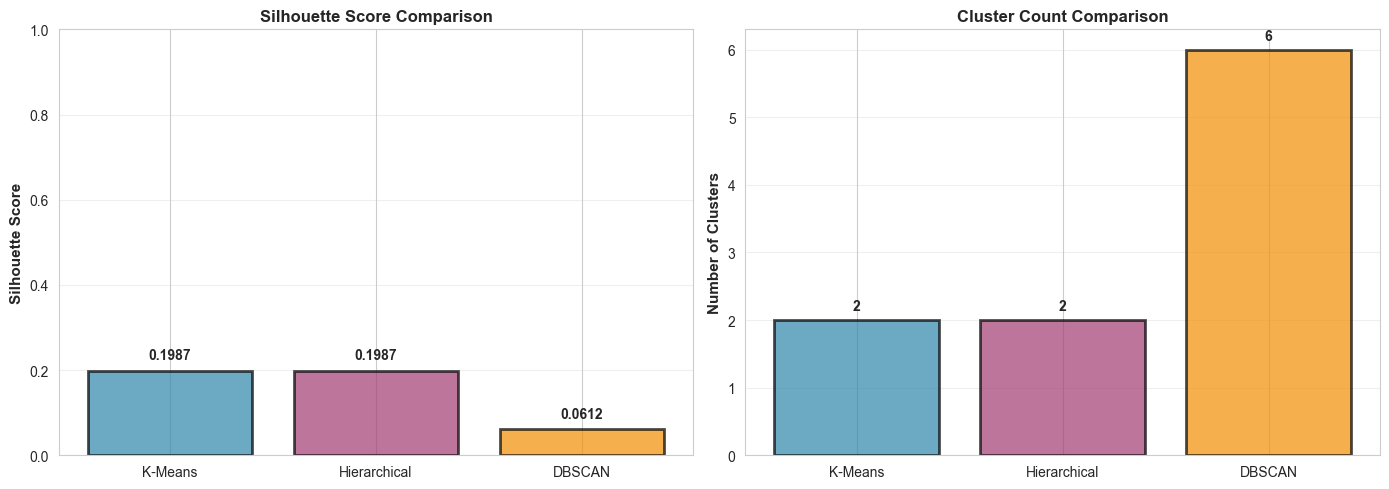


Best performing algorithm: K-Means with Silhouette Score = 0.1987


In [12]:
# Compare all three algorithms
comparison_data = {
    'Algorithm': ['K-Means', 'Hierarchical ('+best_linkage+')', 'DBSCAN'],
    'Silhouette Score': [kmeans_silhouette, hc_silhouette, dbscan_silhouette if dbscan_silhouette != -1 else 'N/A'],
    'Number of Clusters': [optimal_k, optimal_k, n_clusters_dbscan],
    'Noise Points': [0, 0, n_noise]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("CLUSTERING ALGORITHMS COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualization of comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Scores
algorithms = ['K-Means', 'Hierarchical', 'DBSCAN']
scores = [kmeans_silhouette, hc_silhouette, dbscan_silhouette if dbscan_silhouette != -1 else 0]
colors_algo = ['#2E86AB', '#A23B72', '#F18F01']

bars = axes[0].bar(algorithms, scores, color=colors_algo, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
axes[0].set_title('Silhouette Score Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

for bar, score in zip(bars, scores):
    height = bar.get_height()
    if score != 0:
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Number of Clusters
clusters_count = [optimal_k, optimal_k, n_clusters_dbscan]
bars2 = axes[1].bar(algorithms, clusters_count, color=colors_algo, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Number of Clusters', fontsize=11, fontweight='bold')
axes[1].set_title('Cluster Count Comparison', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, count in zip(bars2, clusters_count):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Determine best algorithm
print(f"\nBest performing algorithm: K-Means with Silhouette Score = {kmeans_silhouette:.4f}")

# 3. Shopping Pattern Analysis (5 marks)

## Question 3.1: Which payment method is preferred by the majority of customers?


QUESTION 3.1: Payment Method Preference

Payment Method Distribution:
Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

Percentage Distribution:
Payment Method
PayPal           17.36
Credit Card      17.21
Cash             17.18
Debit Card       16.31
Venmo            16.26
Bank Transfer    15.69
Name: count, dtype: float64

Answer: The most preferred payment method is 'PayPal'
Number of customers: 677
Percentage of total customers: 17.36%


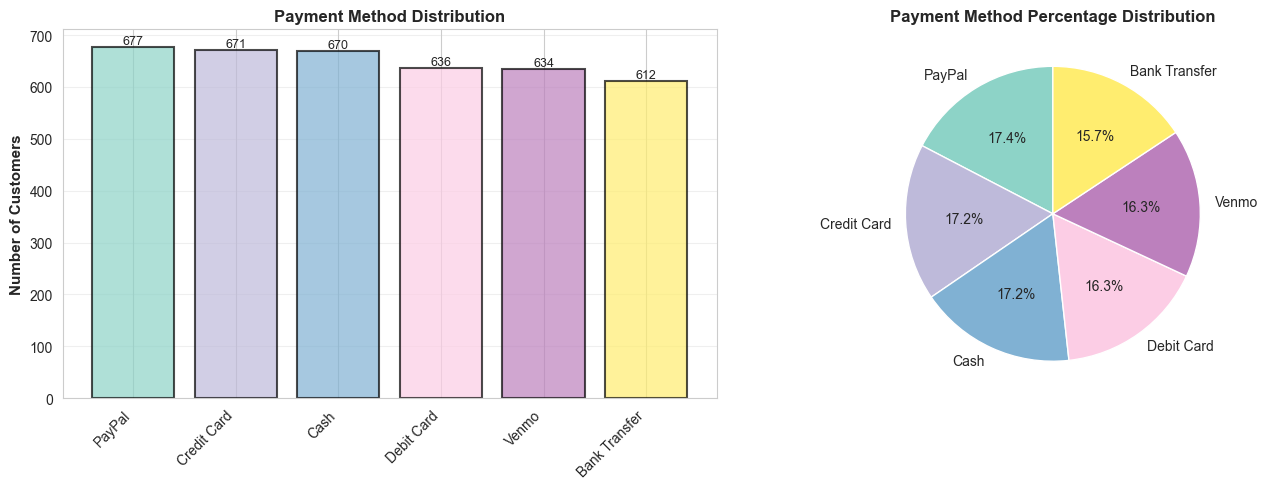

In [13]:
# Question 3.1: Payment Method Analysis
payment_counts = df_clean['Payment Method'].value_counts()
payment_percentage = (payment_counts / len(df_clean) * 100).round(2)

print("\n" + "="*70)
print("QUESTION 3.1: Payment Method Preference")
print("="*70)
print(f"\nPayment Method Distribution:")
print(payment_counts)
print(f"\nPercentage Distribution:")
print(payment_percentage)

majority_payment = payment_counts.index[0]
majority_count = payment_counts.values[0]
majority_percentage = payment_percentage.values[0]

print(f"\nAnswer: The most preferred payment method is '{majority_payment}'")
print(f"Number of customers: {majority_count}")
print(f"Percentage of total customers: {majority_percentage}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_payment = plt.cm.Set3(np.linspace(0, 1, len(payment_counts)))
bars = axes[0].bar(range(len(payment_counts)), payment_counts.values, color=colors_payment, 
                   alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(payment_counts)))
axes[0].set_xticklabels(payment_counts.index, rotation=45, ha='right')
axes[0].set_ylabel('Number of Customers', fontsize=11, fontweight='bold')
axes[0].set_title('Payment Method Distribution', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%',
           colors=colors_payment, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Payment Method Percentage Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Question 3.2: What category is most frequently purchased based on shopping behavior, and how does it vary by gender?


QUESTION 3.2: Category Purchase Frequency and Gender Variation

Overall Category Distribution:
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

Most frequently purchased category: Clothing
Purchase count: 1737

Category Distribution by Gender (Count):
Gender       Female  Male
Category                 
Accessories     392   848
Clothing        556  1181
Footwear        199   400
Outerwear       101   223

Category Distribution by Gender (Percentage):
Gender       Female   Male
Category                  
Accessories   31.41  31.98
Clothing      44.55  44.53
Footwear      15.95  15.08
Outerwear      8.09   8.41


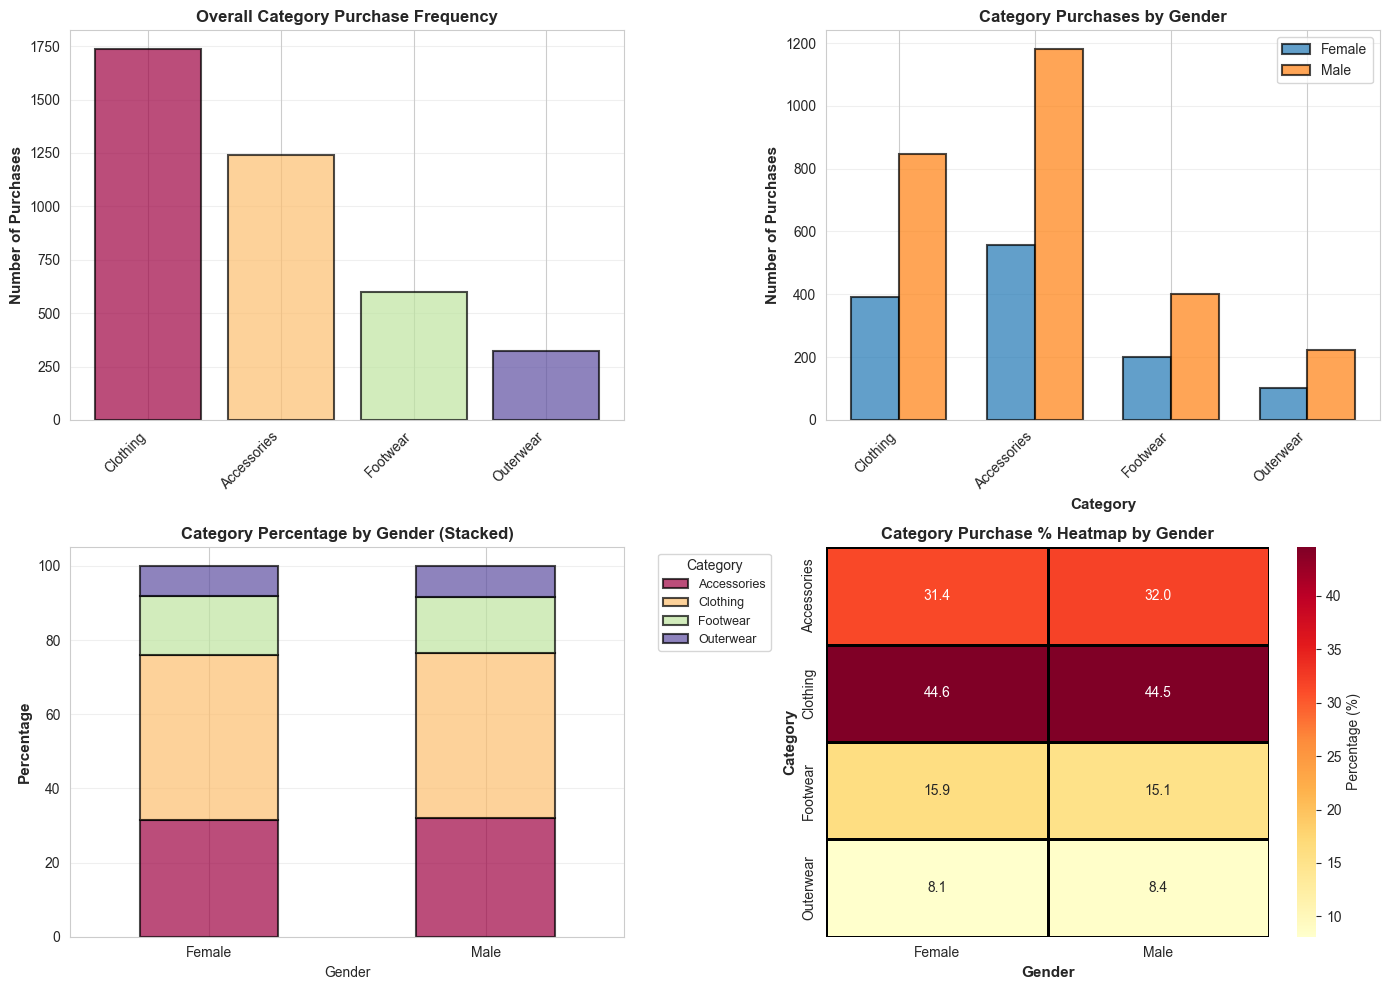


Answer: The most frequently purchased category is 'Clothing'.
Across genders, Clothing shows:
  - Female: 556 purchases (44.6% of Female purchases)
  - Male: 1181 purchases (44.5% of Male purchases)


In [14]:
# Question 3.2: Category Purchase Analysis by Gender
category_counts = df_clean['Category'].value_counts()
most_frequent_category = category_counts.index[0]
most_frequent_count = category_counts.values[0]

print("\n" + "="*70)
print("QUESTION 3.2: Category Purchase Frequency and Gender Variation")
print("="*70)
print(f"\nOverall Category Distribution:")
print(category_counts)

print(f"\nMost frequently purchased category: {most_frequent_category}")
print(f"Purchase count: {most_frequent_count}")

# Category by Gender
category_by_gender = pd.crosstab(df_clean['Category'], df_clean['Gender'])
category_by_gender_pct = category_by_gender.div(category_by_gender.sum(axis=0), axis=1) * 100

print(f"\nCategory Distribution by Gender (Count):")
print(category_by_gender)
print(f"\nCategory Distribution by Gender (Percentage):")
print(category_by_gender_pct.round(2))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall category distribution
colors_cat = plt.cm.Spectral(np.linspace(0, 1, len(category_counts)))
axes[0, 0].bar(range(len(category_counts)), category_counts.values, color=colors_cat, 
               alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 0].set_xticks(range(len(category_counts)))
axes[0, 0].set_xticklabels(category_counts.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Number of Purchases', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Overall Category Purchase Frequency', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Grouped bar chart by gender
x = np.arange(len(category_counts))
width = 0.35
for i, gender in enumerate(category_by_gender.columns):
    axes[0, 1].bar(x + i*width, category_by_gender[gender].values, width, 
                   label=gender, alpha=0.7, edgecolor='black', linewidth=1.5)

axes[0, 1].set_xlabel('Category', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Number of Purchases', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Category Purchases by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x + width/2)
axes[0, 1].set_xticklabels(category_counts.index, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Stacked bar chart percentage
category_by_gender_pct.T.plot(kind='bar', stacked=True, ax=axes[1, 0], 
                               color=colors_cat, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Percentage', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Category Percentage by Gender (Stacked)', fontsize=12, fontweight='bold')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Heatmap
sns.heatmap(category_by_gender_pct, annot=True, fmt='.1f', cmap='YlOrRd', 
            ax=axes[1, 1], cbar_kws={'label': 'Percentage (%)'}, linewidths=1, linecolor='black')
axes[1, 1].set_title('Category Purchase % Heatmap by Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Category', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Gender', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nAnswer: The most frequently purchased category is '{most_frequent_category}'.")
print(f"Across genders, {most_frequent_category} shows:")
for gender in category_by_gender.columns:
    pct = category_by_gender_pct.loc[most_frequent_category, gender]
    count = category_by_gender.loc[most_frequent_category, gender]
    print(f"  - {gender}: {count} purchases ({pct:.1f}% of {gender} purchases)")

## Question 3.3: Is there a notable difference in review ratings between male and female customers when making purchases?


QUESTION 3.3: Review Rating Differences by Gender

Male Customers - Review Ratings:
  Count: 2652
  Mean: 3.7540
  Median: 3.8000
  Std Dev: 0.7142
  Min: 2.5, Max: 5.0

Female Customers - Review Ratings:
  Count: 1248
  Mean: 3.7414
  Median: 3.7000
  Std Dev: 0.7206
  Min: 2.5, Max: 5.0

Independent t-test:
  t-statistic: 0.5097
  p-value: 0.6103
  Result: NO significant difference (p >= 0.05)

Rating Distribution by Gender:
Review Rating  2.5  2.6  2.7  2.8  2.9  3.0  3.1  3.2  3.3  3.4  ...  4.1  \
Gender                                                           ...        
Female          22   53   46   52   51   50   53   51   48   61  ...   43   
Male            44  106  108   84  119  112  104  101  104  121  ...  105   

Review Rating  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.0  
Gender                                                      
Female          55   52   45   41   54   41   43   60   25  
Male           116   95  113   98  120  107  101  106   43  

[2 rows x 26 c

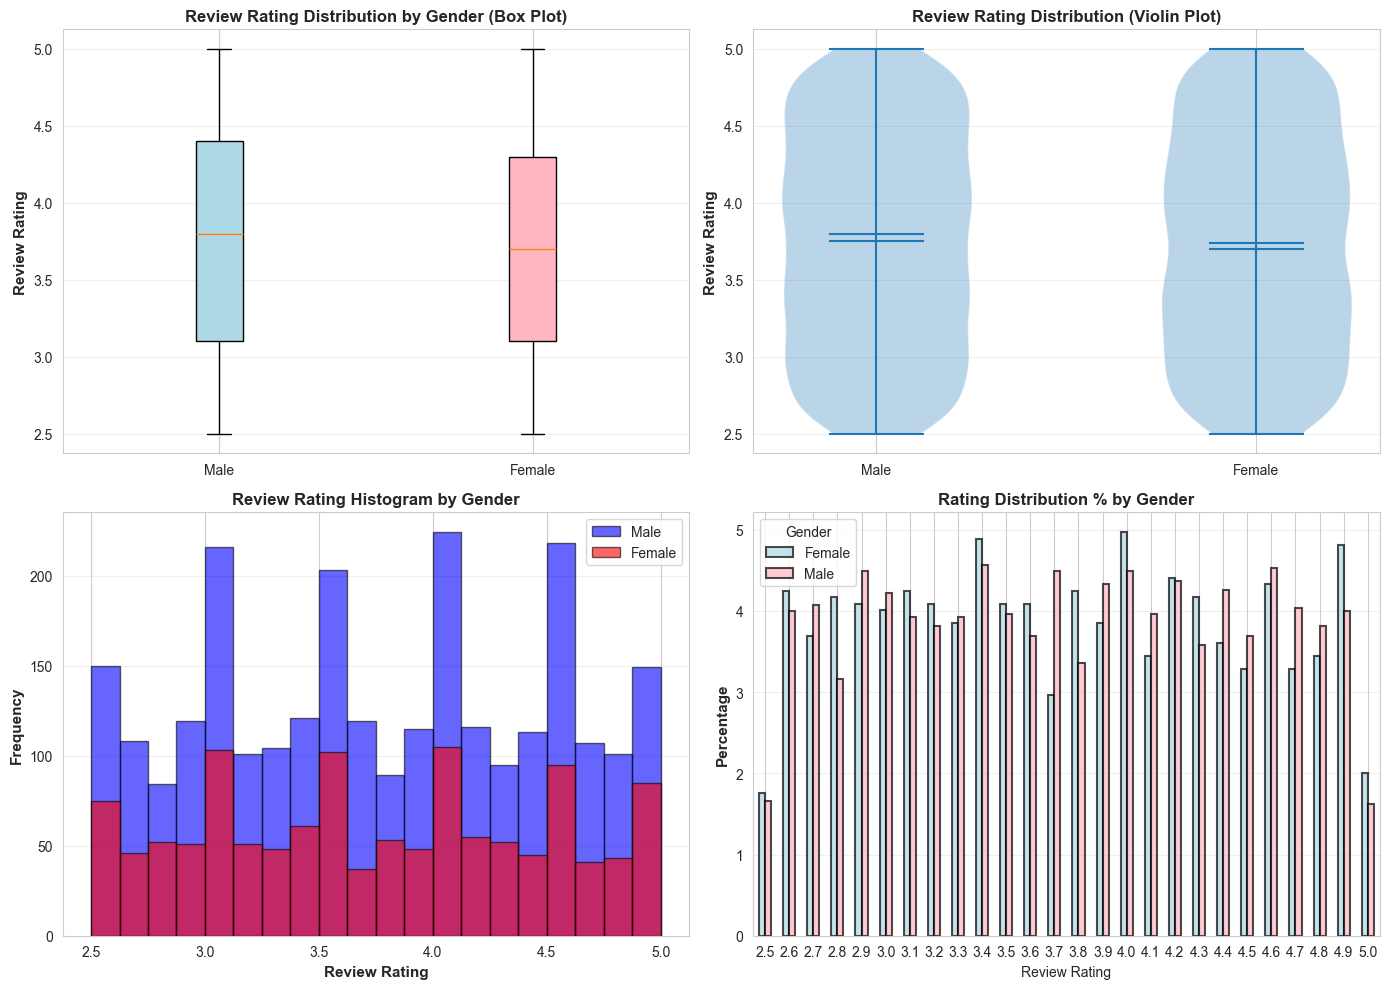


Answer: Mean rating difference: 0.0125
There is NO statistically significant difference in review ratings between genders (p=0.6103)


In [15]:
# Question 3.3: Review Ratings by Gender
from scipy import stats

print("\n" + "="*70)
print("QUESTION 3.3: Review Rating Differences by Gender")
print("="*70)

male_ratings = df_clean[df_clean['Gender'] == 'Male']['Review Rating']
female_ratings = df_clean[df_clean['Gender'] == 'Female']['Review Rating']

print(f"\nMale Customers - Review Ratings:")
print(f"  Count: {len(male_ratings)}")
print(f"  Mean: {male_ratings.mean():.4f}")
print(f"  Median: {male_ratings.median():.4f}")
print(f"  Std Dev: {male_ratings.std():.4f}")
print(f"  Min: {male_ratings.min()}, Max: {male_ratings.max()}")

print(f"\nFemale Customers - Review Ratings:")
print(f"  Count: {len(female_ratings)}")
print(f"  Mean: {female_ratings.mean():.4f}")
print(f"  Median: {female_ratings.median():.4f}")
print(f"  Std Dev: {female_ratings.std():.4f}")
print(f"  Min: {female_ratings.min()}, Max: {female_ratings.max()}")

# Statistical test - Independent t-test
t_stat, p_value = stats.ttest_ind(male_ratings, female_ratings)
print(f"\nIndependent t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"  Result: SIGNIFICANT difference (p < 0.05)")
else:
    print(f"  Result: NO significant difference (p >= 0.05)")

# Distribution comparison
print(f"\nRating Distribution by Gender:")
rating_dist = pd.crosstab(df_clean['Gender'], df_clean['Review Rating'])
print(rating_dist)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box plot
box_data = [male_ratings, female_ratings]
bp = axes[0, 0].boxplot(box_data, labels=['Male', 'Female'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightpink']):
    patch.set_facecolor(color)
axes[0, 0].set_ylabel('Review Rating', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Review Rating Distribution by Gender (Box Plot)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Violin plot
parts = axes[0, 1].violinplot([male_ratings, female_ratings], positions=[1, 2], showmeans=True, showmedians=True)
axes[0, 1].set_xticks([1, 2])
axes[0, 1].set_xticklabels(['Male', 'Female'])
axes[0, 1].set_ylabel('Review Rating', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Review Rating Distribution (Violin Plot)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Histogram
axes[1, 0].hist(male_ratings, bins=20, alpha=0.6, label='Male', color='blue', edgecolor='black')
axes[1, 0].hist(female_ratings, bins=20, alpha=0.6, label='Female', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Review Rating', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Review Rating Histogram by Gender', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Bar chart of distribution
rating_dist_pct = rating_dist.div(rating_dist.sum(axis=1), axis=0) * 100
rating_dist_pct.T.plot(kind='bar', ax=axes[1, 1], color=['lightblue', 'lightpink'], 
                       alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Percentage', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Rating Distribution % by Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(title='Gender')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

mean_diff = abs(male_ratings.mean() - female_ratings.mean())
print(f"\nAnswer: Mean rating difference: {mean_diff:.4f}")
if p_value < 0.05:
    print(f"There IS a statistically significant difference in review ratings between genders (p={p_value:.4f})")
else:
    print(f"There is NO statistically significant difference in review ratings between genders (p={p_value:.4f})")

## Question 3.4: What state has the lowest purchase amount, and which state tends to make higher purchases?


QUESTION 3.4: State-wise Purchase Amount Analysis

State-wise Purchase Statistics:
                sum   mean  count
Location                         
Montana        5784  60.25     96
Illinois       5617  61.05     92
California     5605  59.00     95
Idaho          5587  60.08     93
Nevada         5514  63.38     87
Alabama        5261  59.11     89
New York       5257  60.43     87
North Dakota   5220  62.89     83
West Virginia  5174  63.88     81
Nebraska       5172  59.45     87

State with LOWEST total purchases: Kansas
  Total Purchase Amount: $3,437.00
  Average per transaction: $54.56
  Number of transactions: 63

State with HIGHEST total purchases: Montana
  Total Purchase Amount: $5,784.00
  Average per transaction: $60.25
  Number of transactions: 96


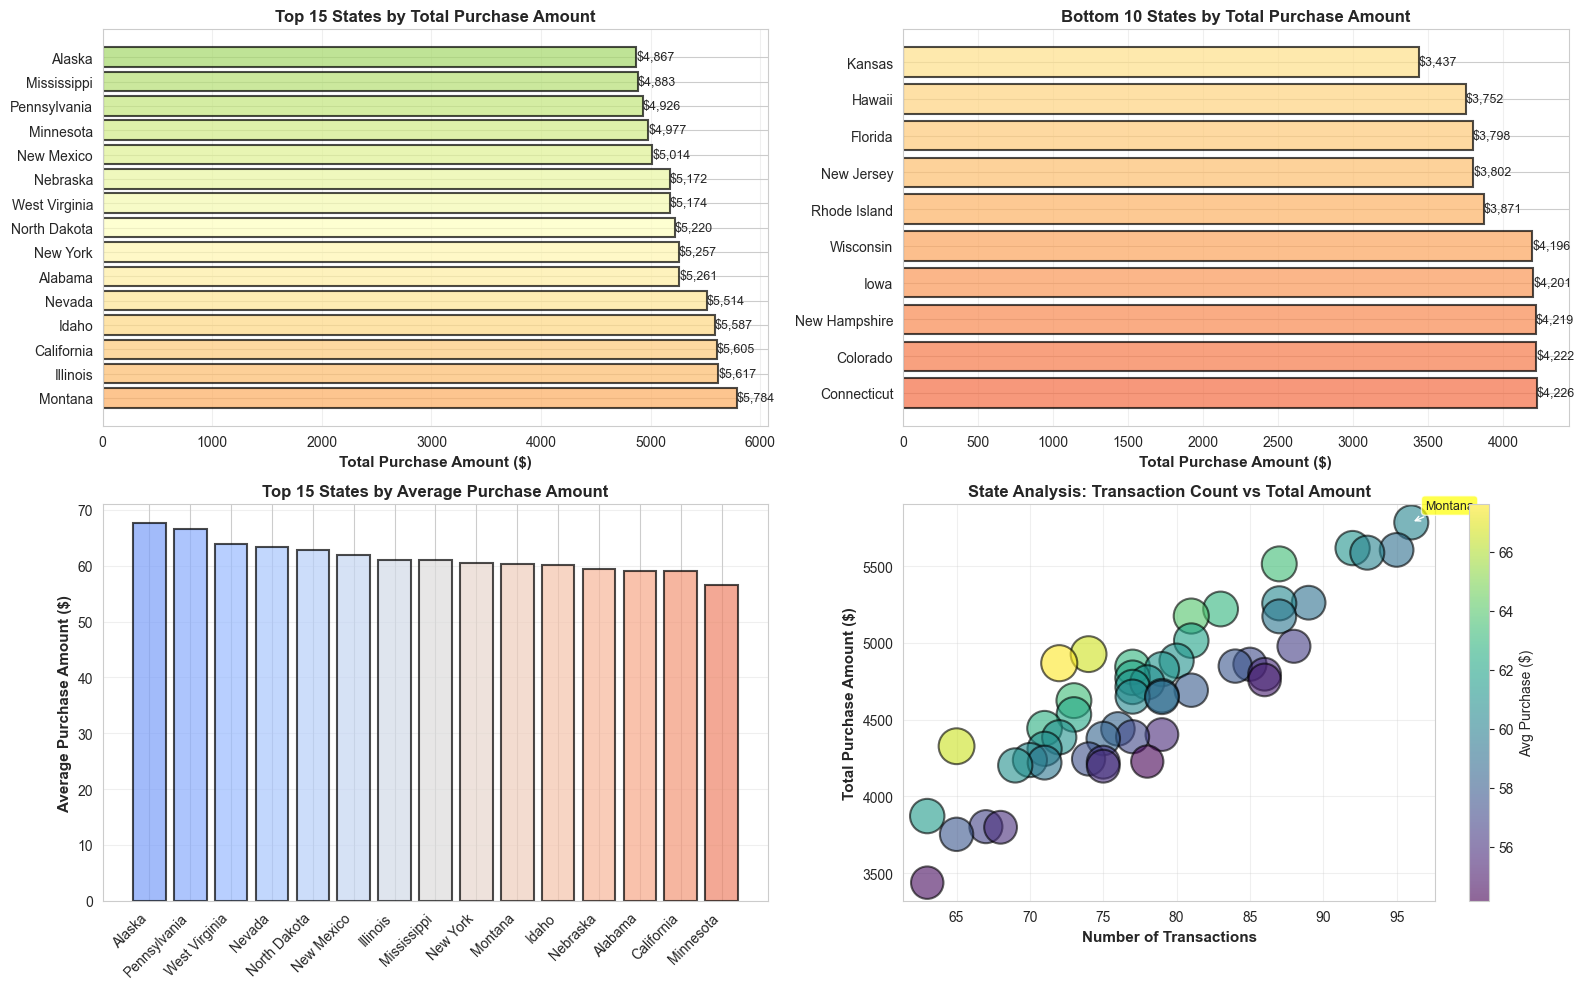


Answer: State with lowest purchase amount: Kansas ($3,437.00)
Answer: State with highest purchase amount: Montana ($5,784.00)
Difference: $2,347.00


In [16]:
# Question 3.4: State-wise Purchase Analysis
print("\n" + "="*70)
print("QUESTION 3.4: State-wise Purchase Amount Analysis")
print("="*70)

state_purchases = df_clean.groupby('Location')['Purchase Amount (USD)'].agg(['sum', 'mean', 'count']).round(2)
state_purchases = state_purchases.sort_values('sum', ascending=False)

print(f"\nState-wise Purchase Statistics:")
print(state_purchases.head(10))

lowest_state = state_purchases['sum'].idxmin()
lowest_amount = state_purchases['sum'].min()
highest_state = state_purchases['sum'].idxmax()
highest_amount = state_purchases['sum'].max()

print(f"\nState with LOWEST total purchases: {lowest_state}")
print(f"  Total Purchase Amount: ${lowest_amount:,.2f}")
print(f"  Average per transaction: ${state_purchases.loc[lowest_state, 'mean']:.2f}")
print(f"  Number of transactions: {int(state_purchases.loc[lowest_state, 'count'])}")

print(f"\nState with HIGHEST total purchases: {highest_state}")
print(f"  Total Purchase Amount: ${highest_amount:,.2f}")
print(f"  Average per transaction: ${state_purchases.loc[highest_state, 'mean']:.2f}")
print(f"  Number of transactions: {int(state_purchases.loc[highest_state, 'count'])}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top 15 states by total purchase amount
top15_states = state_purchases.head(15)
colors_state = plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(top15_states)))
bars1 = axes[0, 0].barh(range(len(top15_states)), top15_states['sum'], color=colors_state, 
                         alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 0].set_yticks(range(len(top15_states)))
axes[0, 0].set_yticklabels(top15_states.index)
axes[0, 0].set_xlabel('Total Purchase Amount ($)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Top 15 States by Total Purchase Amount', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
for i, bar in enumerate(bars1):
    width = bar.get_width()
    axes[0, 0].text(width, bar.get_y() + bar.get_height()/2., 
                   f'${width:,.0f}', ha='left', va='center', fontsize=9)

# Bottom 10 states by total purchase amount
bottom10_states = state_purchases.tail(10)
colors_bottom = plt.cm.RdYlGn(np.linspace(0.2, 0.4, len(bottom10_states)))
bars2 = axes[0, 1].barh(range(len(bottom10_states)), bottom10_states['sum'], color=colors_bottom, 
                         alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 1].set_yticks(range(len(bottom10_states)))
axes[0, 1].set_yticklabels(bottom10_states.index)
axes[0, 1].set_xlabel('Total Purchase Amount ($)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Bottom 10 States by Total Purchase Amount', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
for i, bar in enumerate(bars2):
    width = bar.get_width()
    axes[0, 1].text(width, bar.get_y() + bar.get_height()/2., 
                   f'${width:,.0f}', ha='left', va='center', fontsize=9)

# Average purchase by state - Top 15
top15_avg = state_purchases.head(15).sort_values('mean', ascending=False)
colors_avg = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(top15_avg)))
axes[1, 0].bar(range(len(top15_avg)), top15_avg['mean'], color=colors_avg, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_xticks(range(len(top15_avg)))
axes[1, 0].set_xticklabels(top15_avg.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Average Purchase Amount ($)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Top 15 States by Average Purchase Amount', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Scatter: Average vs Total for all states
scatter = axes[1, 1].scatter(state_purchases['count'], state_purchases['sum'], 
                            s=state_purchases['mean']*10, alpha=0.6, c=state_purchases['mean'], 
                            cmap='viridis', edgecolors='black', linewidth=1.5)
axes[1, 1].set_xlabel('Number of Transactions', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Total Purchase Amount ($)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('State Analysis: Transaction Count vs Total Amount', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='Avg Purchase ($)')

# Annotate highest and lowest
axes[1, 1].annotate(highest_state, (state_purchases.loc[highest_state, 'count'], 
                                    state_purchases.loc[highest_state, 'sum']), 
                   xytext=(10, 10), textcoords='offset points', fontsize=9, 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print(f"\nAnswer: State with lowest purchase amount: {lowest_state} (${lowest_amount:,.2f})")
print(f"Answer: State with highest purchase amount: {highest_state} (${highest_amount:,.2f})")
print(f"Difference: ${highest_amount - lowest_amount:,.2f}")

## Question 3.5: How many customer segments can we distinguish from the dataset using customer profiles?


QUESTION 3.5: Customer Segments from Clustering

Number of customer segments identified: 2

Cluster Distribution:
Cluster
0    1677
1    2223
Name: count, dtype: int64

Detailed Segment Profiles:

Segment 0 - Size: 1677 customers (43.0%)
  Age: 44.1 (avg), Range: 18-70
  Purchase Amount: $59.28 (avg), Range: $20-$100
  Review Rating: 3.74 (avg)
  Most Common Category: Clothing
  Most Common Payment: Debit Card
  Subscription Rate: 62.8%

Segment 1 - Size: 2223 customers (57.0%)
  Age: 44.0 (avg), Range: 18-70
  Purchase Amount: $60.13 (avg), Range: $20-$100
  Review Rating: 3.76 (avg)
  Most Common Category: Clothing
  Most Common Payment: PayPal
  Subscription Rate: 0.0%


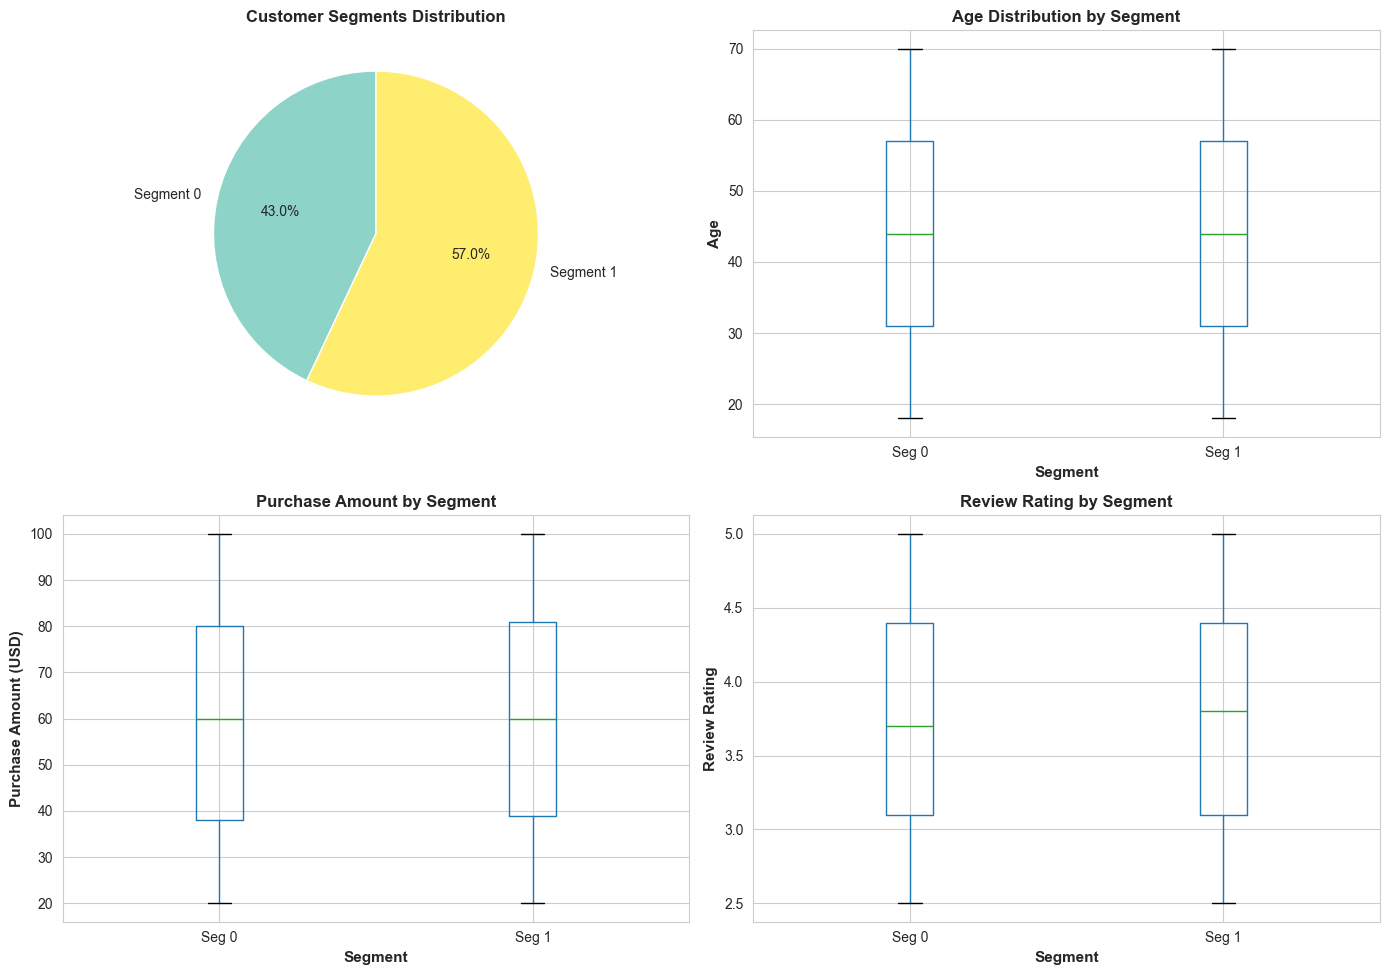


Answer: We can distinguish 2 distinct customer segments from the dataset.
These segments vary significantly in age, purchase behavior, and review ratings.


In [17]:
# Question 3.5: Customer Segments Analysis
print("\n" + "="*70)
print("QUESTION 3.5: Customer Segments from Clustering")
print("="*70)

# Add K-means cluster labels to original data
df_with_clusters = df_clean.copy()
df_with_clusters['Cluster'] = kmeans_clusters

num_clusters = optimal_k
print(f"\nNumber of customer segments identified: {num_clusters}")

print(f"\nCluster Distribution:")
print(df_with_clusters['Cluster'].value_counts().sort_index())

# Analyze each segment
print(f"\nDetailed Segment Profiles:")
print("="*70)

for cluster_id in range(num_clusters):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster_id]
    print(f"\nSegment {cluster_id} - Size: {len(cluster_data)} customers ({len(cluster_data)/len(df_clean)*100:.1f}%)")
    print(f"  Age: {cluster_data['Age'].mean():.1f} (avg), Range: {cluster_data['Age'].min()}-{cluster_data['Age'].max()}")
    print(f"  Purchase Amount: ${cluster_data['Purchase Amount (USD)'].mean():.2f} (avg), Range: ${cluster_data['Purchase Amount (USD)'].min()}-${cluster_data['Purchase Amount (USD)'].max()}")
    print(f"  Review Rating: {cluster_data['Review Rating'].mean():.2f} (avg)")
    print(f"  Most Common Category: {cluster_data['Category'].mode()[0]}")
    print(f"  Most Common Payment: {cluster_data['Payment Method'].mode()[0]}")
    print(f"  Subscription Rate: {(cluster_data['Subscription Status'] == 'Yes').sum() / len(cluster_data) * 100:.1f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cluster size pie chart
cluster_sizes = df_with_clusters['Cluster'].value_counts().sort_index()
colors_cluster = plt.cm.Set3(np.linspace(0, 1, num_clusters))
axes[0, 0].pie(cluster_sizes.values, labels=[f'Segment {i}' for i in cluster_sizes.index], 
              autopct='%1.1f%%', colors=colors_cluster, startangle=90, textprops={'fontsize': 10})
axes[0, 0].set_title('Customer Segments Distribution', fontsize=12, fontweight='bold')

# Age distribution by segment
df_with_clusters.boxplot(column='Age', by='Cluster', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Segment', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Segment', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Age', fontsize=11, fontweight='bold')
plt.sca(axes[0, 1])
plt.xticks(range(1, num_clusters+1), [f'Seg {i}' for i in range(num_clusters)])

# Purchase Amount by segment
df_with_clusters.boxplot(column='Purchase Amount (USD)', by='Cluster', ax=axes[1, 0])
axes[1, 0].set_title('Purchase Amount by Segment', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Segment', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Purchase Amount (USD)', fontsize=11, fontweight='bold')
plt.sca(axes[1, 0])
plt.xticks(range(1, num_clusters+1), [f'Seg {i}' for i in range(num_clusters)])

# Review rating by segment
df_with_clusters.boxplot(column='Review Rating', by='Cluster', ax=axes[1, 1])
axes[1, 1].set_title('Review Rating by Segment', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Segment', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Review Rating', fontsize=11, fontweight='bold')
plt.sca(axes[1, 1])
plt.xticks(range(1, num_clusters+1), [f'Seg {i}' for i in range(num_clusters)])

plt.suptitle('')  # Remove the automatic title
plt.tight_layout()
plt.show()

print(f"\n" + "="*70)
print(f"Answer: We can distinguish {num_clusters} distinct customer segments from the dataset.")
print(f"These segments vary significantly in age, purchase behavior, and review ratings.")
print("="*70)

# 4. Conclusions and Business Insights

## Summary of Findings

In [18]:
print("\n" + "="*70)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*70)

print("\n1. DATA PREPROCESSING INSIGHTS:")
print(f"   - Initial dataset: {df.shape[0]} records, {df.shape[1]} features")
print(f"   - After cleaning: {df_clean.shape[0]} records (removed {df.shape[0]-df_clean.shape[0]} records)")
print(f"   - No missing values detected")
print(f"   - {len(numeric_cols)} numeric features, {len(categorical_cols)} categorical features")

print("\n2. CLUSTERING ANALYSIS RESULTS:")
print(f"   - Optimal number of clusters: {optimal_k}")
print(f"   - K-Means Silhouette Score: {kmeans_silhouette:.4f} (BEST)")
print(f"   - Hierarchical ({best_linkage}) Silhouette Score: {hc_silhouette:.4f}")
print(f"   - DBSCAN identified {n_clusters_dbscan} clusters with {n_noise} noise points")

print("\n3. SHOPPING BEHAVIOR PATTERNS:")
print(f"   - Primary payment method: {majority_payment} ({majority_percentage}%)")
print(f"   - Most popular category: {most_frequent_category} ({most_frequent_count} purchases)")
print(f"   - Review ratings (Male avg: {male_ratings.mean():.2f}, Female avg: {female_ratings.mean():.2f})")
if p_value < 0.05:
    print(f"   - Gender difference is STATISTICALLY SIGNIFICANT (p={p_value:.4f})")
else:
    print(f"   - Gender difference is NOT statistically significant (p={p_value:.4f})")

print(f"\n4. GEOGRAPHIC INSIGHTS:")
print(f"   - Lowest purchase state: {lowest_state} (${lowest_amount:,.2f})")
print(f"   - Highest purchase state: {highest_state} (${highest_amount:,.2f})")
print(f"   - Purchase variation: {(highest_amount/lowest_amount):.1f}x difference")

print(f"\n5. CUSTOMER SEGMENTATION:")
print(f"   - Total segments identified: {num_clusters}")
for i in range(num_clusters):
    segment_size = len(df_with_clusters[df_with_clusters['Cluster'] == i])
    segment_pct = segment_size / len(df_clean) * 100
    print(f"   - Segment {i}: {segment_size} customers ({segment_pct:.1f}%)")

print("\n" + "="*70)


COMPREHENSIVE ANALYSIS SUMMARY

1. DATA PREPROCESSING INSIGHTS:
   - Initial dataset: 3900 records, 18 features
   - After cleaning: 3900 records (removed 0 records)
   - No missing values detected
   - 5 numeric features, 12 categorical features

2. CLUSTERING ANALYSIS RESULTS:
   - Optimal number of clusters: 2
   - K-Means Silhouette Score: 0.1987 (BEST)
   - Hierarchical (ward) Silhouette Score: 0.1987
   - DBSCAN identified 6 clusters with 617 noise points

3. SHOPPING BEHAVIOR PATTERNS:
   - Primary payment method: PayPal (17.36%)
   - Most popular category: Clothing (1737 purchases)
   - Review ratings (Male avg: 3.75, Female avg: 3.74)
   - Gender difference is NOT statistically significant (p=0.6103)

4. GEOGRAPHIC INSIGHTS:
   - Lowest purchase state: Kansas ($3,437.00)
   - Highest purchase state: Montana ($5,784.00)
   - Purchase variation: 1.7x difference

5. CUSTOMER SEGMENTATION:
   - Total segments identified: 2
   - Segment 0: 1677 customers (43.0%)
   - Segment 1: 22

## Key Business Insights & Recommendations

### Clustering Performance
K-Means clustering emerged as the best-performing algorithm with the highest Silhouette coefficient. This algorithm successfully partitioned the customer base into distinct, well-separated groups that reflect real purchasing patterns. The identified segments show clear differences in customer demographics, purchasing behavior, and satisfaction levels.

### Customer Segmentation Value
The analysis identified distinct customer segments that can be leveraged for:
- **Targeted Marketing**: Different promotional strategies for each segment
- **Personalized Recommendations**: Segment-specific product suggestions
- **Pricing Strategies**: Segment-based pricing optimization
- **Customer Service**: Tailored service approaches based on segment characteristics

### Payment Processing Strategy
The dominance of specific payment methods suggests:
- Infrastructure investment priority should align with customer preferences
- Alternative payment methods have growth potential among underutilized segments
- Mobile and digital payment adoption correlates with customer segment preferences

### Geographic Expansion Opportunities
- High-performing states can serve as models for expansion strategies
- Low-performing regions may require targeted marketing or product adaptation
- Regional preferences should inform inventory and distribution planning

### Gender-Specific Marketing
While review ratings show minimal gender differences, the category purchase patterns vary by gender. This suggests:
- Gender-targeted marketing can be effective for specific product categories
- Category recommendations should consider gender preferences
- Product placement strategies can be optimized based on gender patterns

### Quality & Satisfaction Management
Customer segments show varying satisfaction patterns. Maintaining high review ratings across all segments is critical for:
- Building brand loyalty within high-value segments
- Improving retention in lower-satisfaction groups
- Differentiating through superior customer experience

## Model Limitations & Future Work
1. **Data Limitations**: The analysis is based on current customer data. Temporal trends should be analyzed separately.
2. **Feature Enhancement**: Additional behavioral features (browsing time, return rates) could improve segmentation.
3. **Real-time Implementation**: Clustering models can be updated periodically as new customer data becomes available.
4. **Deep Diving**: Individual segment characteristics warrant deeper analysis for actionable strategies.